In [2]:
import pandas as pd
import numpy as np

import os

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score,accuracy_score,recall_score,confusion_matrix,roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [3]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/vigneshvenkateswaran/bot-iot/data_26.csv
/kaggle/input/datasets/vigneshvenkateswaran/bot-iot/data_33.csv
/kaggle/input/datasets/vigneshvenkateswaran/bot-iot/data_49.csv
/kaggle/input/datasets/vigneshvenkateswaran/bot-iot/data_44.csv
/kaggle/input/datasets/vigneshvenkateswaran/bot-iot/data_38.csv
/kaggle/input/datasets/vigneshvenkateswaran/bot-iot/data_22.csv
/kaggle/input/datasets/vigneshvenkateswaran/bot-iot/data_30.csv
/kaggle/input/datasets/vigneshvenkateswaran/bot-iot/data_57.csv
/kaggle/input/datasets/vigneshvenkateswaran/bot-iot/data_46.csv
/kaggle/input/datasets/vigneshvenkateswaran/bot-iot/data_58.csv
/kaggle/input/datasets/vigneshvenkateswaran/bot-iot/data_21.csv
/kaggle/input/datasets/vigneshvenkateswaran/bot-iot/data_59.csv
/kaggle/input/datasets/vigneshvenkateswaran/bot-iot/data_32.csv
/kaggle/input/datasets/vigneshvenkateswaran/bot-iot/data_69.csv
/kaggle/input/datasets/vigneshvenkateswaran/bot-iot/data_19.csv
/kaggle/input/datasets/vigneshvenkateswa

In [4]:
file_paths = [
    "/kaggle/input/datasets/vigneshvenkateswaran/bot-iot/data_1.csv",
    "/kaggle/input/datasets/vigneshvenkateswaran/bot-iot/data_10.csv",
     "/kaggle/input/datasets/vigneshvenkateswaran/bot-iot/data_60.csv"
]

dfs = []
target_size = 500000  

for path in file_paths:
    df = pd.read_csv(path)
    

    if "category" in df.columns:
        df = df[df["category"] != "Normal"]
    
    
    df = df.head(target_size)
    

    cols_to_drop = ["pkSeqID", "stime", "ltime", "seq"]
    for col in cols_to_drop:
        if col in df.columns:
            df.drop(columns=[col], inplace=True)
    
    dfs.append(df)


df = pd.concat(dfs, ignore_index=True)
print("Merged dataset shape:", df.shape)
print(df["category"].value_counts())




/tmp/ipykernel_59/1899709718.py:11: DtypeWarning: Columns (5,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)
/tmp/ipykernel_59/1899709718.py:11: DtypeWarning: Columns (5,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


Merged dataset shape: (1500000, 31)
category
Reconnaissance    500000
DoS               500000
DDoS              500000
Name: count, dtype: int64


In [5]:
#shuffle
df = df.sample(frac=1).reset_index(drop=True)
df.head(10)

,flgs,proto,saddr,sport,daddr,dport,pkts,bytes,state,dur,...,spkts,dpkts,sbytes,dbytes,rate,srate,drate,attack,category,subcategory
0,e,tcp,192.168.100.149,57044,192.168.100.3,25047,2,120,RST,0.023728,...,1,1,60,60,42.144302,0.000000,0.0,1,Reconnaissance,Service_Scan
1,e,udp,192.168.100.150,10642.0,192.168.100.3,80.0,7,420,INT,15.390629,...,7,0,420,0,0.389848,0.389848,0.0,1,DDoS,UDP
2,e s,tcp,192.168.100.150,9896.0,192.168.100.6,80.0,5,676,RST,56.256374,...,4,1,616,60,0.071103,0.053327,0.0,1,DoS,TCP
3,e,tcp,192.168.100.149,57044,192.168.100.3,47506,2,120,RST,0.020319,...,1,1,60,60,49.215019,0.000000,0.0,1,Reconnaissance,Service_Scan
4,e s,tcp,192.168.100.150,30783.0,192.168.100.6,80.0,4,522,RST,36.061745,...,3,1,462,60,0.083191,0.055460,0.0,1,DoS,TCP
5,e,udp,192.168.100.147,36850,192.168.100.3,50612,1,60,INT,0.000000,...,1,0,60,0,0.000000,0.000000,0.0,1,Reconnaissance,Service_Scan
6,e s,tcp,192.168.100.149,54326.0,192.168.100.7,80.0,3,462,REQ,37.762493,...,3,0,462,0,0.052963,0.052963,0.0,1,DoS,TCP
7,e,tcp,192.168.100.150,56304,192.168.100.3,17703,2,120,RST,0.045494,...,1,1,60,60,21.980921,0.000000,0.0,1,Reconnaissance,Service_Scan
8,e,icmp,192.168.100.3,0x0303,192.168.100.150,0xd207,1,70,URP,0.000000,...,1,0,70,0,0.000000,0.000000,0.0,1,Reconnaissance,Service_Scan
9,e,udp,192.168.100.148,4936,192.168.100.3,80,11,660,INT,14.134632,...,11,0,660,0,0.707482,0.707482,0.0,1,DDoS,UDP


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
pkts,1500000.0,5.903823,10.278016,1.0,2.000000,5.000000,9.000000,4.879000e+03
bytes,1500000.0,511.789559,5759.555879,60.0,120.000000,522.000000,660.000000,2.536017e+06
dur,1500000.0,20.698602,33.103954,0.0,0.028176,15.586910,38.349766,1.716233e+03
mean,1500000.0,1.197912,1.605446,0.0,0.000142,0.037325,2.869080,4.878934e+00
stddev,1500000.0,0.463678,0.690166,0.0,0.000000,0.008630,1.021309,2.499505e+00
smac,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dmac,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sum,1500000.0,3.924058,5.230167,0.0,0.000143,0.048372,10.590330,4.583837e+01
min,1500000.0,0.581048,1.104405,0.0,0.000000,0.000380,0.143438,4.869134e+00
max,1500000.0,1.639819,2.105297,0.0,0.000143,0.047686,4.240499,4.999999e+00


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500000 entries, 0 to 1499999
Data columns (total 31 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   flgs          1500000 non-null  object 
 1   proto         1500000 non-null  object 
 2   saddr         1500000 non-null  object 
 3   sport         1499787 non-null  object 
 4   daddr         1500000 non-null  object 
 5   dport         1499787 non-null  object 
 6   pkts          1500000 non-null  int64  
 7   bytes         1500000 non-null  int64  
 8   state         1500000 non-null  object 
 9   dur           1500000 non-null  float64
 10  mean          1500000 non-null  float64
 11  stddev        1500000 non-null  float64
 12  smac          0 non-null        float64
 13  dmac          0 non-null        float64
 14  sum           1500000 non-null  float64
 15  min           1500000 non-null  float64
 16  max           1500000 non-null  float64
 17  soui          0 non-null   

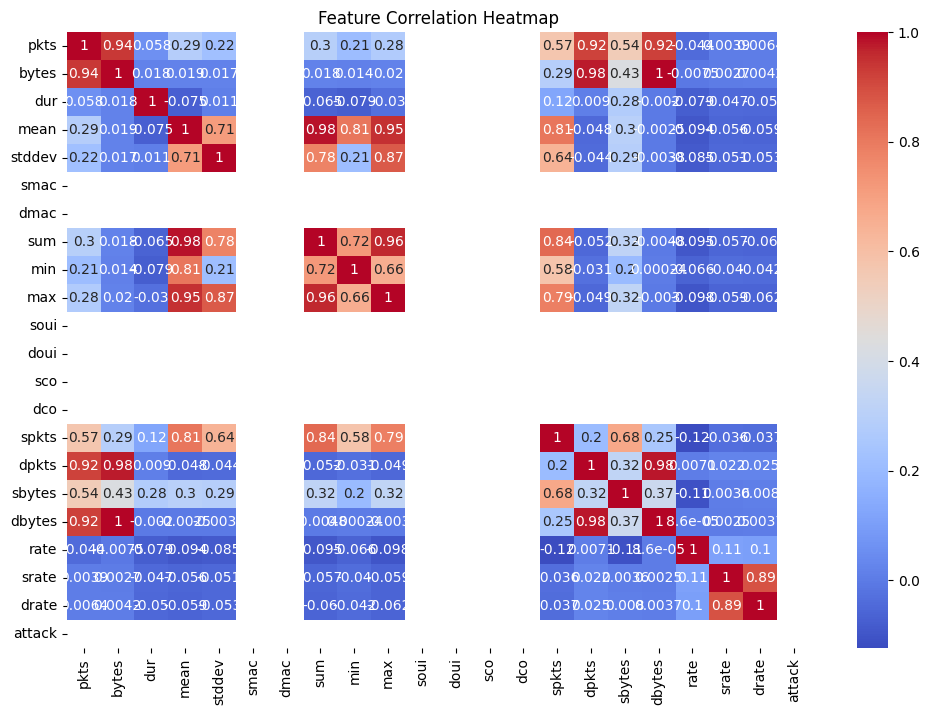

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns


corr_matrix = df.corr(numeric_only=True)


plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=True)

plt.title("Feature Correlation Heatmap")
plt.show()  

In [8]:
df=df.drop(['smac','dmac','sco','dco','saddr','soui','doui','daddr','attack','subcategory '],axis=1)

In [9]:
df.columns

Index(['flgs', 'proto', 'sport', 'dport', 'pkts', 'bytes', 'state', 'dur',
       'mean', 'stddev', 'sum', 'min', 'max', 'spkts', 'dpkts', 'sbytes',
       'dbytes', 'rate', 'srate', 'drate', 'category'],
      dtype='object')

In [11]:
df=df.drop_duplicates()

In [12]:
df.isnull().sum()

flgs          0
proto         0
sport       208
dport       208
pkts          0
bytes         0
state         0
dur           0
mean          0
stddev        0
sum           0
min           0
max           0
spkts         0
dpkts         0
sbytes        0
dbytes        0
rate          0
srate         0
drate         0
category      0
dtype: int64

In [16]:
df=df.dropna(subset=['sport','dport'])

In [17]:
cols_to_convert = ['sport', 'dport']
df[cols_to_convert] = df[cols_to_convert].apply(pd.to_numeric, errors='coerce').astype('Int64')

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1475299 entries, 0 to 1499999
Data columns (total 21 columns):
 #   Column    Non-Null Count    Dtype  
---  ------    --------------    -----  
 0   flgs      1475299 non-null  object 
 1   proto     1475299 non-null  object 
 2   sport     1475299 non-null  Int64  
 3   dport     1475299 non-null  Int64  
 4   pkts      1475299 non-null  int64  
 5   bytes     1475299 non-null  int64  
 6   state     1475299 non-null  object 
 7   dur       1475299 non-null  float64
 8   mean      1475299 non-null  float64
 9   stddev    1475299 non-null  float64
 10  sum       1475299 non-null  float64
 11  min       1475299 non-null  float64
 12  max       1475299 non-null  float64
 13  spkts     1475299 non-null  int64  
 14  dpkts     1475299 non-null  int64  
 15  sbytes    1475299 non-null  int64  
 16  dbytes    1475299 non-null  int64  
 17  rate      1475299 non-null  float64
 18  srate     1475299 non-null  float64
 19  drate     1475299 non-null

Skew before transformation:

pkts: 330.3064
bytes: 381.2969
dur: 8.9131
mean: 0.7538
stddev: 1.0925
sum: 0.6700
min: 1.6931
max: 0.5527
spkts: 7.9499
dpkts: 420.2073
sbytes: 31.2192
dbytes: 389.6124
rate: 25.5976
srate: 75.3331
drate: 67.2438

Skew after transformation:

pkts: -0.0681
bytes: -0.6119
dur: -0.5565
mean: 0.7538
stddev: 0.8886
sum: 0.6700
min: 1.4211
max: 0.5527
spkts: -0.1311
dpkts: 0.9554
sbytes: -0.7408
dbytes: 0.2534
rate: 1.6921
srate: 7.1497
drate: 8.2379


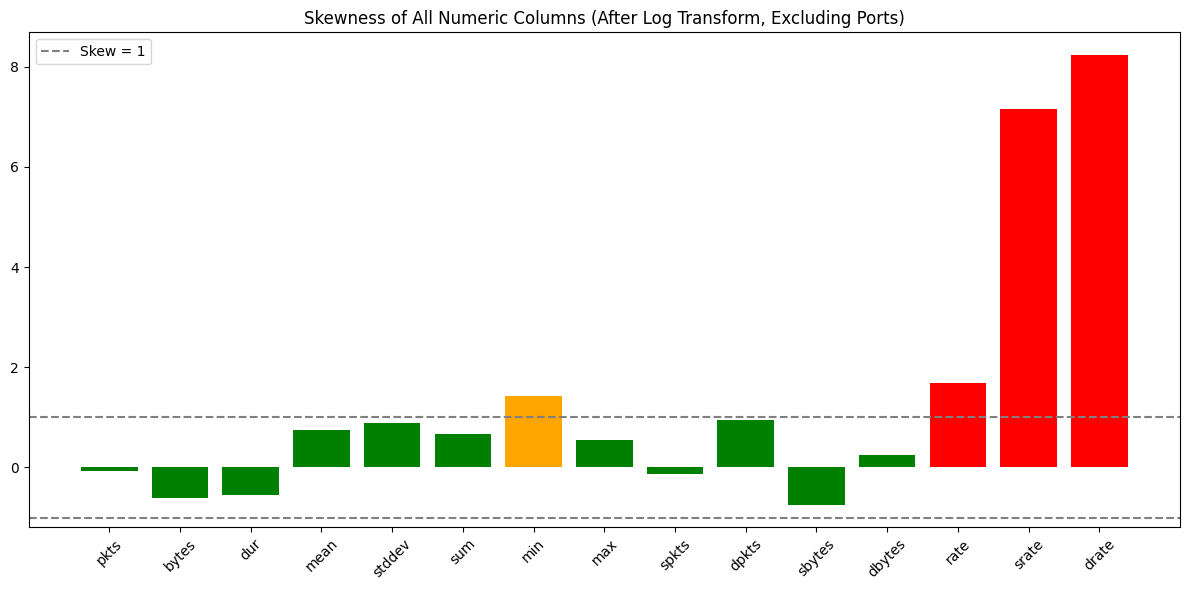

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


num_cols = df.select_dtypes(include='number')


num_cols = num_cols.drop(columns=['dport','sport'], errors='ignore')


skew_vals = num_cols.skew()
print("Skew before transformation:\n")
for col, skew_val in skew_vals.items():
    print(f"{col}: {skew_val:.4f}")

skewed_cols = skew_vals[abs(skew_vals) > 1].index

for col in skewed_cols:
    df[col] = np.log1p(df[col])


new_skew_vals = df[num_cols.columns].skew()
print("\nSkew after transformation:\n")
for col, skew_val in new_skew_vals.items():
    print(f"{col}: {skew_val:.4f}")


skew_vals_dict = new_skew_vals.to_dict()

skew_df = pd.DataFrame(list(skew_vals_dict.items()), columns=['Column', 'Skew'])


colors = []
for val in skew_df['Skew']:
    if abs(val) > 1.5:
        colors.append('red')
    elif abs(val) > 1:
        colors.append('orange')
    else:
        colors.append('green')


plt.figure(figsize=(12,6))
plt.bar(skew_df['Column'], skew_df['Skew'], color=colors)
plt.xticks(rotation=45)
plt.title('Skewness of All Numeric Columns (After Log Transform, Excluding Ports)')
plt.axhline(1, color='gray', linestyle='--', label='Skew = 1')
plt.axhline(-1, color='gray', linestyle='--')
plt.legend()
plt.tight_layout()
plt.show()

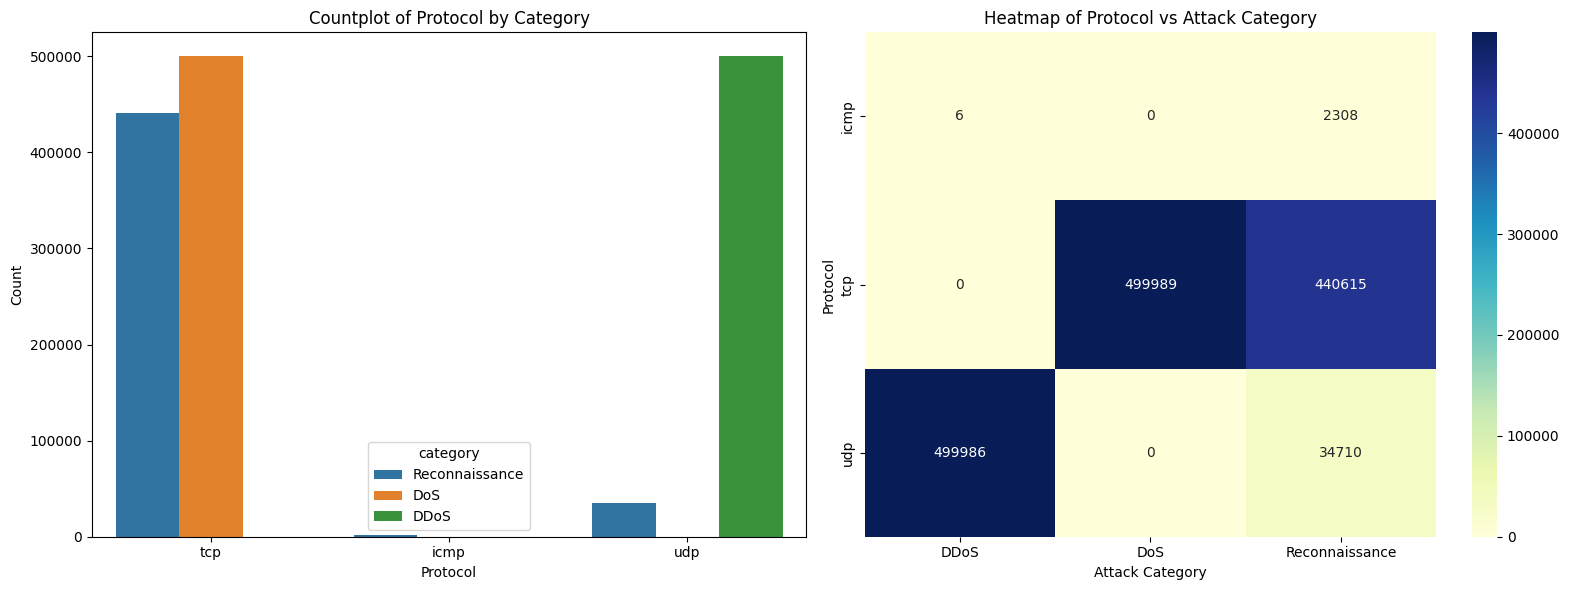

In [98]:
#the relationships between protocol type and attack category
plt.figure(figsize=(16,6))
plt.subplot(1, 2, 1)
sns.countplot(x='proto', hue='category', data=df)
plt.title("Countplot of Protocol by Category")
plt.xlabel("Protocol")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
heatmap_data = pd.crosstab(df['proto'], df['category'])
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlGnBu')
plt.ylabel("Protocol")
plt.xlabel("Attack Category")
plt.title("Heatmap of Protocol vs Attack Category")

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


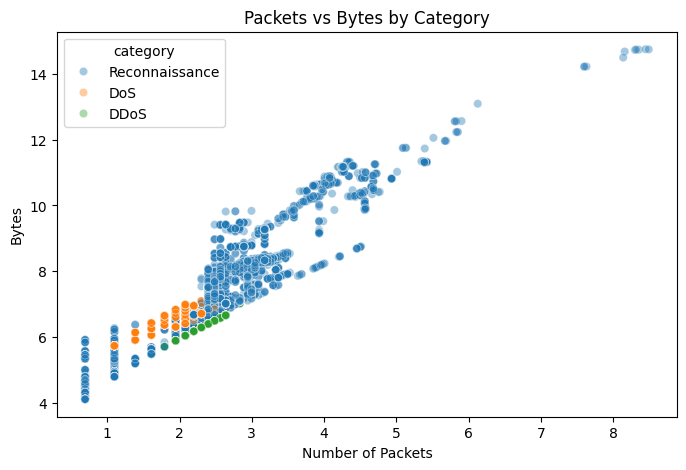

In [99]:
#لما عدد الباكتس وحجمهم كبر احتمالية حدوث الكونسينس كبيرة
plt.figure(figsize=(8,5))
sns.scatterplot(x='pkts', y='bytes', hue='category', data=df, alpha=0.4)



plt.title("Packets vs Bytes by Category")
plt.xlabel("Number of Packets")
plt.ylabel("Bytes")
plt.show()



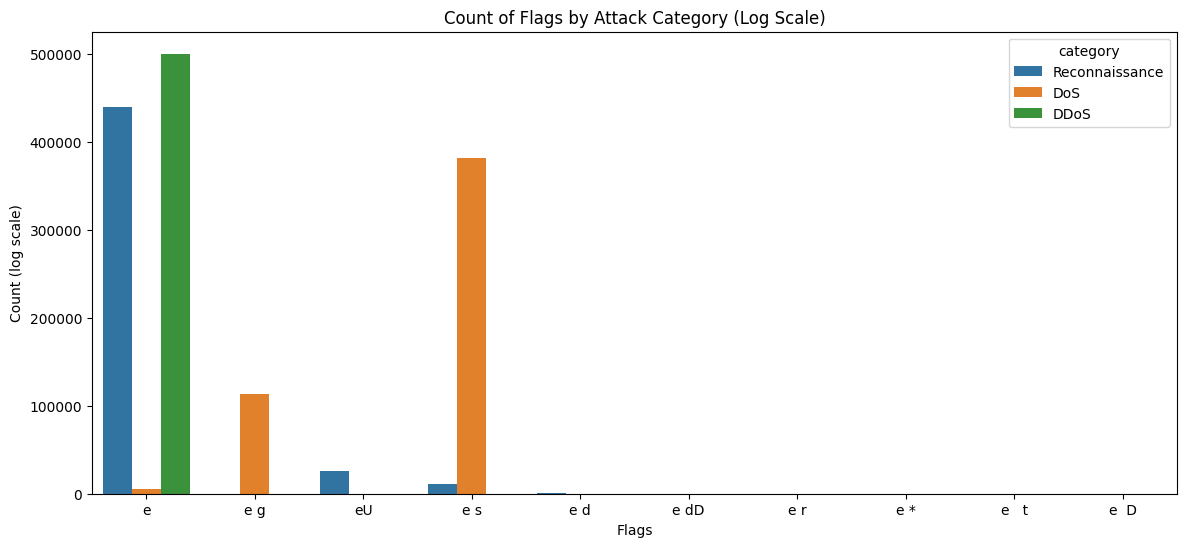

In [100]:
#relationships between flags and attack category
plt.figure(figsize=(14,6))
ax = sns.countplot(x='flgs', hue='category', data=df)



plt.title("Count of Flags by Attack Category (Log Scale)") 
plt.xlabel("Flags")
plt.ylabel("Count (log scale)")
plt.show()

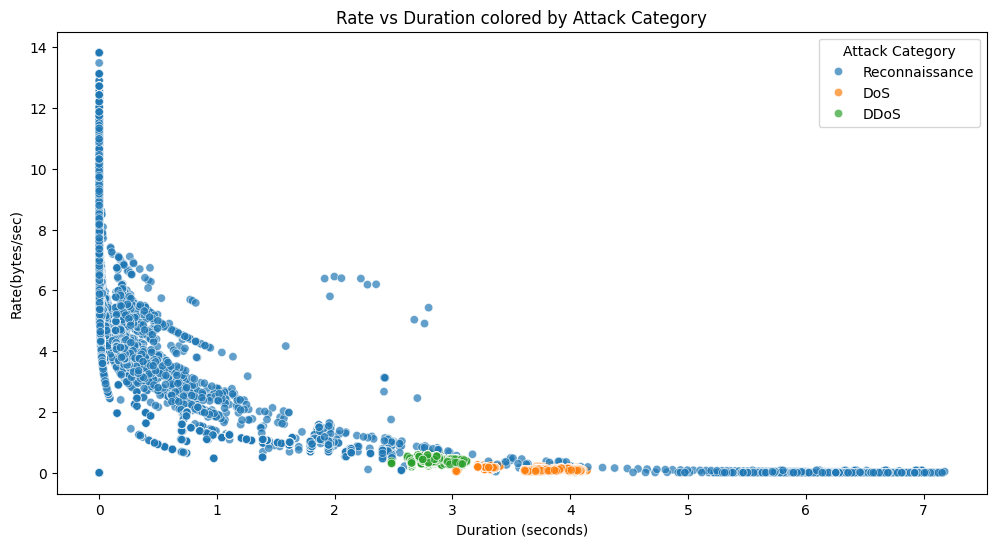

In [101]:
#الاكثر سرعة في ارسال البينانات ريكونسينس وكمان معدل ارساله مش ثابت
#على عكس ان dos , ddos بيكون وقتهم ثابت ايا كان نوع الهدف او المهمة
plt.figure(figsize=(12,6))
sns.scatterplot(x='dur', y='rate', hue='category', data=df, alpha=0.7)
plt.title("Rate vs Duration colored by Attack Category")
plt.xlabel("Duration (seconds)")
plt.ylabel("Rate(bytes/sec)")
plt.legend(title='Attack Category')
plt.show()

In [102]:
diff_bytes=abs(df['sbytes'] - df['dbytes'])

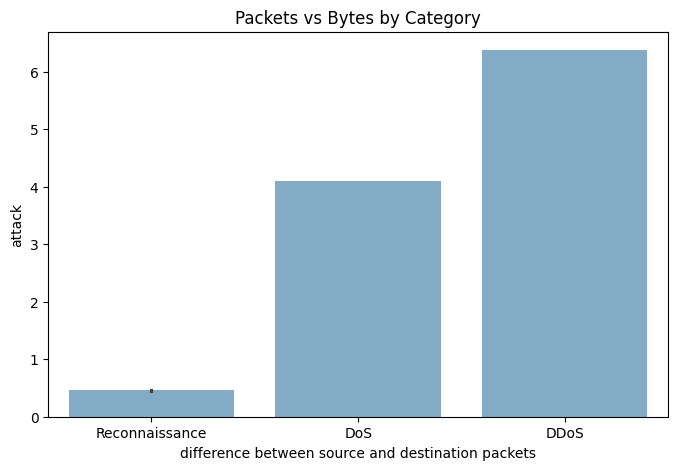

In [103]:

 #بيتبعت باكتس كتيرة اوي من السورس اكتر من اللي لازم تستلمها المستقبلل ddos attack#
plt.figure(figsize=(8,5))
sns.barplot(x=df['category'],y=diff_bytes, alpha=0.6)
plt.title('Packets vs Bytes by Category')
plt.xlabel('difference between source and destination packets')
plt.ylabel('attack')

plt.show()

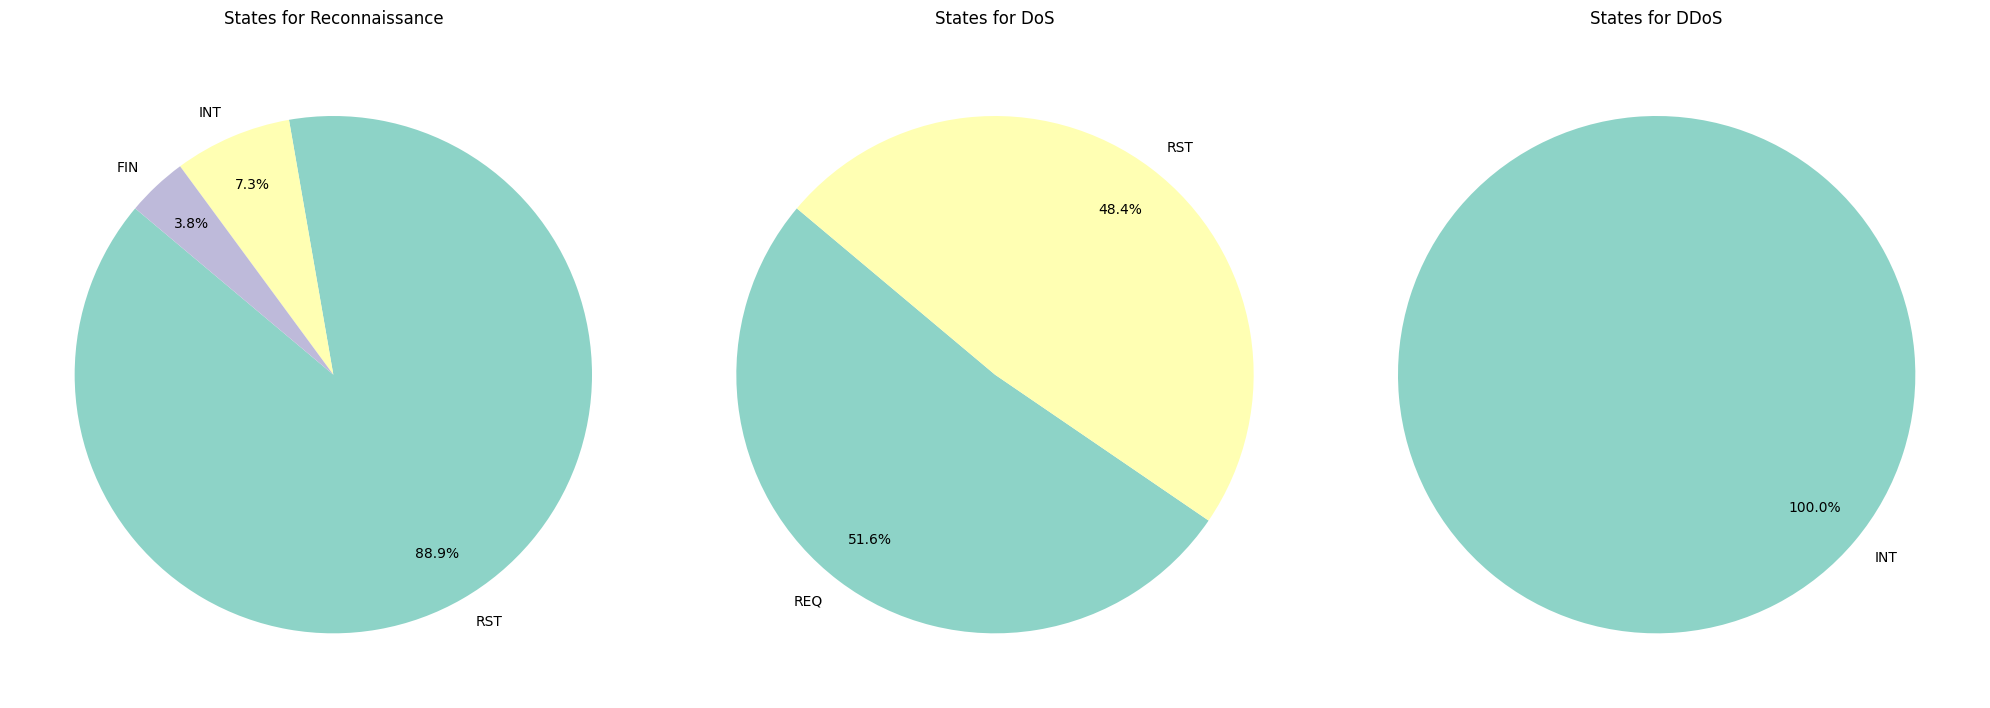

In [104]:
import matplotlib.pyplot as plt

categories = df['category'].unique()

plt.figure(figsize=(20, 10))

for i, cat in enumerate(categories):
    plt.subplot(1, len(categories), i+1)

    state_counts = df[df['category'] == cat]['state'].value_counts()

    state_counts = state_counts[state_counts / state_counts.sum() > 0.01]

    colors = plt.cm.Set3.colors[:len(state_counts)]

    plt.pie(
        state_counts,
        labels=state_counts.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=colors,
        pctdistance=0.8,
        labeldistance=1.1,
        textprops={'fontsize': 10}
    )

    plt.title(f"States for {cat}", pad=20)

plt.tight_layout()
plt.show()

In [20]:
df.head(20)

,flgs,proto,sport,dport,pkts,bytes,state,dur,mean,stddev,...,min,max,spkts,dpkts,sbytes,dbytes,rate,srate,drate,category
0,e,tcp,57044,25047,1.098612,4.795791,RST,0.023451,0.023728,0.000000,...,0.023451,0.023728,0.693147,0.693147,4.110874,4.110874,3.764550,0.000000,0.000000,Reconnaissance
1,e,udp,10642,80,2.079442,6.042633,INT,2.796710,2.932347,0.702991,...,1.166587,4.374539,2.079442,0.000000,6.042633,0.000000,0.329194,0.329194,0.000000,DDoS
2,e s,tcp,9896,80,1.791759,6.517671,RST,4.047539,0.008367,0.014387,...,0.000000,0.033466,1.609438,0.693147,6.424869,4.110874,0.068689,0.051954,0.000000,DoS
3,e,tcp,57044,47506,1.098612,4.795791,RST,0.020115,0.020319,0.000000,...,0.020115,0.020319,0.693147,0.693147,4.110874,4.110874,3.916314,0.000000,0.000000,Reconnaissance
4,e s,tcp,30783,80,1.609438,6.259581,RST,3.612585,0.015759,0.022042,...,0.000000,0.047277,1.386294,0.693147,6.137727,4.110874,0.079911,0.053977,0.000000,DoS
5,e,udp,36850,50612,0.693147,4.110874,INT,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.693147,0.000000,4.110874,0.000000,0.000000,0.000000,0.000000,Reconnaissance
6,e s,tcp,54326,80,1.386294,6.137727,REQ,3.657453,0.000000,0.000000,...,0.000000,0.000000,1.386294,0.000000,6.137727,0.000000,0.051608,0.051608,0.000000,DoS
7,e,tcp,56304,17703,1.098612,4.795791,RST,0.044490,0.045494,0.000000,...,0.044490,0.045494,0.693147,0.693147,4.110874,4.110874,3.134664,0.000000,0.000000,Reconnaissance
9,e,udp,4936,80,2.484907,6.493754,INT,2.716986,3.771236,0.506951,...,1.344832,4.238886,2.484907,0.000000,6.493754,0.000000,0.535020,0.535020,0.000000,DDoS
10,e,udp,53726,80,2.484907,6.493754,INT,2.847345,4.331569,0.562317,...,1.450263,4.871242,2.484907,0.000000,6.493754,0.000000,0.479762,0.479762,0.000000,DDoS


In [21]:
import pandas as pd


numeric_cols = df.select_dtypes(include='number')  # only numeric columns


range_df = pd.DataFrame({
    'min': numeric_cols.min(),
    'max': numeric_cols.max()
})

print(range_df)

             min        max
sport        0.0    65535.0
dport        1.0    65535.0
pkts    0.693147     8.4929
bytes   4.110874  14.746106
dur          0.0   6.704766
mean         0.0   4.878934
stddev       0.0   1.252622
sum          0.0  17.559826
min          0.0   1.769707
max          0.0   4.999999
spkts   0.693147   6.413459
dpkts        0.0   8.418698
sbytes  4.110874  11.080526
dbytes       0.0  14.726438
rate         0.0  13.815512
srate        0.0  12.968215
drate        0.0  12.968215


In [22]:

def port_to_group(port):
    if 0 <= port <= 1023:
        return 'Well‑Known'
    elif 1024 <= port <= 49151:
        return 'Registered Ports'
    elif 49152 <= port <= 65535:
        return 'Dynamic / Private Ports'
    else:
        return 'Custom / Non‑standard'

df['dport'] =df['dport'].apply(port_to_group)
df['sport'] =df['sport'].apply(port_to_group)

print(df['dport'].head())
print(df['sport'].head())


0    Registered Ports
1          Well‑Known
2          Well‑Known
3    Registered Ports
4          Well‑Known
Name: dport, dtype: object
0    Dynamic / Private Ports
1           Registered Ports
2           Registered Ports
3    Dynamic / Private Ports
4           Registered Ports
Name: sport, dtype: object


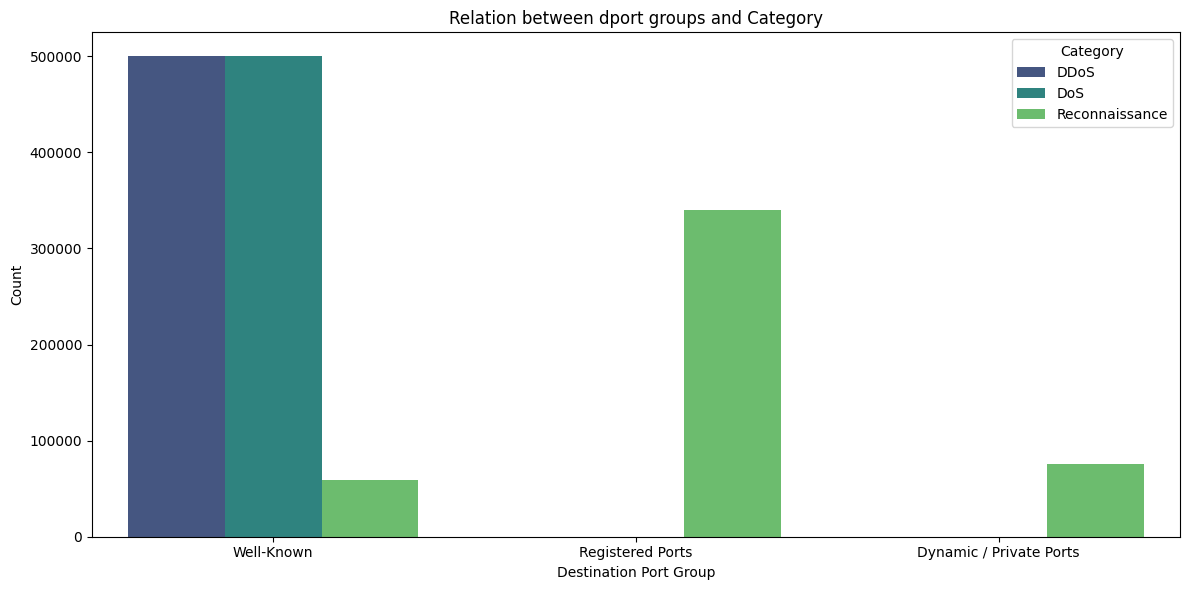

In [23]:
port_counts = df.groupby(['category', 'dport']).size().reset_index(name='count')

plt.figure(figsize=(12,6))
sns.barplot(data=port_counts, x='dport', y='count', hue='category', palette='viridis')
plt.title('Relation between dport groups and Category')
plt.xlabel('Destination Port Group')
plt.ylabel('Count')
plt.legend(title='Category')
plt.tight_layout()
plt.show()

#### model

In [24]:
x=df.drop('category' , axis=1)
y=df['category']

In [25]:
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.8 , random_state=42)

In [26]:
x_train['flgs'].value_counts()

flgs
e        754096
e s      314191
e g       90719
eU        20940
e d         279
e *           7
e   t         3
e r           3
e dD          1
Name: count, dtype: int64

In [27]:
threshold = 1000


rare_states = x_train['state'].value_counts()[x_train['state'].value_counts() < threshold].index

x_train['state'] = x_train['state'].replace(rare_states, 'Other')
x_test['state'] = x_test['state'].replace(rare_states, 'Other')



rare_flgs = x_train['flgs'].value_counts()[x_train['flgs'].value_counts() < threshold].index

x_train['flgs'] = x_train['flgs'].replace(rare_flgs, 'Other')
x_test['flgs'] = x_test['flgs'].replace(rare_flgs, 'Other')

In [29]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()  


num_cols = x_train.select_dtypes(include='number').columns


x_train[num_cols] = scaler.fit_transform(x_train[num_cols])


x_test[num_cols] = scaler.transform(x_test[num_cols])


In [30]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [31]:
from sklearn.preprocessing import OrdinalEncoder


cat_cols = x_train.select_dtypes(include='object').columns.tolist()


encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)


x_train[cat_cols] = encoder.fit_transform(x_train[cat_cols])


x_test[cat_cols] = encoder.transform(x_test[cat_cols])


print(x_train.head())
print(x_test.head())

         flgs  proto  sport  dport      pkts     bytes  state       dur  \
405279    1.0    1.0    1.0    2.0  0.249484  0.239854    1.0  0.427519   
1361482   1.0    1.0    1.0    2.0  0.239982  0.232335    1.0  0.416298   
807573    1.0    1.0    1.0    2.0  0.206345  0.205315    1.0  0.458441   
330747    1.0    1.0    1.0    2.0  0.218564  0.215210    1.0  0.410007   
25160     1.0    1.0    1.0    1.0  0.000000  0.000000    1.0  0.000000   

             mean    stddev       sum       min       max     spkts  dpkts  \
405279   0.588065  0.779998  0.675166  0.000000  0.770690  0.340176    0.0   
1361482  0.785104  0.014457  0.676042  0.887135  0.770175  0.327220    0.0   
807573   0.526332  0.730314  0.604290  0.000000  0.750709  0.281355    0.0   
330747   0.777411  0.738964  0.669418  0.548218  0.976006  0.298017    0.0   
25160    0.000000  0.000000  0.000000  0.000000  0.000000  0.000000    0.0   

           sbytes  dbytes      rate     srate  drate  
405279   0.365829     0.0

In [40]:
!pip install pca

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.4/190.4 kB 6.5 MB/s eta 0:00:00


In [44]:
from pca import pca
pca_model = pca(normalize=True) 
out = pca_model.fit_transform(x_train)


#fig,ax = pca_model.plot()

[17-03-2026 07:56:33] [pca.pca] [INFO] Extracting column labels from dataframe.
[17-03-2026 07:56:33] [pca.pca] [INFO] Extracting row labels from dataframe.
[17-03-2026 07:56:33] [pca.pca] [INFO] Normalizing input data per feature (zero mean and unit variance)..
[17-03-2026 07:56:33] [pca.pca] [INFO] PCA reduction performed to capture at least 95.0% explained variance using 20 columns of the input data.
[17-03-2026 07:56:33] [pca.pca] [INFO] Fit using PCA.
[17-03-2026 07:56:34] [pca.pca] [INFO] Compute loadings and PCs.
[17-03-2026 07:56:34] [pca.pca] [INFO] Compute explained variance.
[17-03-2026 07:56:34] [pca.pca] [INFO] The top 7 principal component(s) explains >= 95.00% of the explained variance.
[17-03-2026 07:56:34] [pca.pca] [INFO] The PCA reduction is performed on 20 variables (columns) of the input dataframe.
[17-03-2026 07:56:34] [pca.pca] [INFO] Fit using PCA.
[17-03-2026 07:56:34] [pca.pca] [INFO] Compute loadings and PCs.
[17-03-2026 07:56:34] [pca.pca] [INFO] Outlier det

In [45]:
topfeat = pd.DataFrame(out['topfeat'])
topfeat

,PC,feature,loading,type
0,PC1,spkts,0.299148,best
1,PC2,flgs,0.460924,best
2,PC3,srate,0.592565,best
3,PC4,dpkts,0.468054,best
4,PC5,sport,0.900410,best
5,PC6,min,0.705998,best
6,PC7,rate,0.680904,best
7,PC7,proto,-0.306988,weak
8,PC7,dport,0.371300,weak
9,PC1,pkts,0.277474,weak


In [47]:
cols = list(topfeat[topfeat['type']=='best']['feature'])
x_train=x_train[cols]
x_train

,spkts,flgs,srate,dpkts,sport,min,rate
405279,0.340176,1.0,0.042000,0.0,1.0,0.000000,0.039424
1361482,0.327220,1.0,0.041772,0.0,1.0,0.887135,0.039210
807573,0.281355,1.0,0.025278,0.0,1.0,0.000000,0.023728
330747,0.298017,1.0,0.036977,0.0,1.0,0.548218,0.034709
25160,0.000000,1.0,0.000000,0.0,1.0,0.000000,0.000000
...,...,...,...,...,...,...,...
263356,0.340176,1.0,0.041995,0.0,1.0,0.000000,0.039419
1438062,0.121173,3.0,0.004033,0.0,0.0,0.000000,0.003786
134080,0.313228,1.0,0.029924,0.0,1.0,0.000000,0.028089
682058,0.262936,1.0,0.022339,0.0,0.0,0.000000,0.020969


In [48]:
cols = list(topfeat[topfeat['type']=='best']['feature'])
x_test=x_test[cols]
x_test

,spkts,flgs,srate,dpkts,sport,min,rate
639028,0.121173,3.0,0.004131,0.130497,0.0,0.000000,0.007558
1062314,0.219003,2.0,0.007377,0.164668,1.0,0.060833,0.010782
981635,0.160182,2.0,0.008456,0.130497,1.0,0.073678,0.012783
169530,0.219003,2.0,0.007362,0.164668,1.0,0.081380,0.010761
976974,0.121173,3.0,0.003672,0.000000,1.0,0.000000,0.003447
...,...,...,...,...,...,...,...
1467369,0.340176,1.0,0.041992,0.000000,1.0,0.000000,0.039417
988196,0.281355,1.0,0.026069,0.000000,1.0,0.000000,0.024470
382138,0.000000,1.0,0.000000,0.082334,1.0,0.000001,0.949828
959653,0.000000,1.0,0.000000,0.082334,0.0,0.001294,0.440130


## Modling

1. Logistic with different Hyperparameters

In [52]:
best_results = {}

3. Random Forest with different Hyperparameters

In [49]:

random_forest_hyperparameters  = [
    {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 1, 'criterion': 'gini'},
   
]

In [50]:
final_accuracies = []
best_rf_accuracy = 0
best_rf_params = None
y_pred_rff= None
for params in random_forest_hyperparameters:
    RF = RandomForestClassifier(random_state=42, **params)
    RF.fit(x_train, y_train)
    y_pred_rf = RF.predict(x_test)
    accuracy = accuracy_score(y_test, y_pred_rf)
    if accuracy > best_rf_accuracy:
        best_rf_accuracy = accuracy
        best_rf_params = params
        y_pred_rff=y_pred_rf
    final_accuracies.append((params, accuracy))

In [53]:
best_results['Random Forest'] = {
    'best_params': best_rf_params,
    'accuracy': best_rf_accuracy
}

In [57]:
y_pred_train = RF.predict(x_train)
y_pred_test = RF.predict(x_test)
accuracy_score(y_test, y_pred_test),accuracy_score(y_train, y_pred_train),

(1.0, 1.0)

In [58]:
x_train.shape, x_test.shape

((1180239, 7), (295060, 7))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0


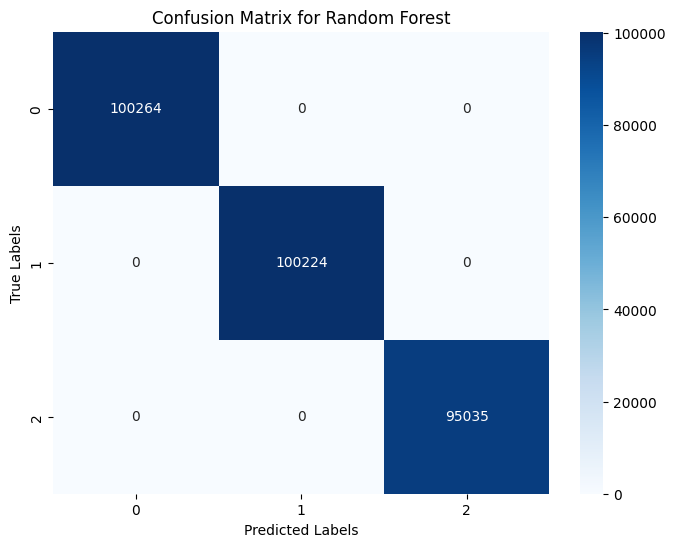

In [135]:
# Evaluate the Random Forest model
evaluate_model(y_test, y_pred_rff, model_name="Random Forest")